#### 1. Loading and Inspecting the Data
#### 2. Data Cleaning
#### 3.Exploratory Data Analysis (EDA)
#### 4.Visualization
#### 5.Advanced Analysis 

### Prerequisites
Before diving into the analysis, ensure you have the necessary libraries installed. You can install them using pip if you haven't already:

In [ ]:
pip install pandas numpy matplotlib seaborn geopandas folium scipy scikit-learn

### 1. Loading and Inspecting the Data
### Objective: Load the dataset and understand its structure.

In [6]:
import pandas as pd

# Load the dataset
file_path = 'earthquake_data.csv'  # Replace with your file path
df = pd.read_csv(file_path)

# Display basic information
print(df.head())  # View the first few rows
print(df.info())  # Check data types and missing values
print(df.describe())  # Summary statistics

                       time  latitude  longitude    depth  mag magType    nst  \
0  2025-02-10T22:48:38.736Z   35.0885    -5.5774   10.000  5.1      mb   70.0   
1  2025-02-10T22:47:05.872Z  -23.1497   -66.8109  204.851  4.7      mb   44.0   
2  2025-02-10T22:37:24.695Z   36.6318    25.6213   10.000  5.1     mww  118.0   
3  2025-02-10T20:16:28.890Z   36.6944    25.6758   10.000  5.2     mww  111.0   
4  2025-02-10T15:15:03.577Z   -9.8140   119.5721   69.344  5.1      mb   76.0   

    gap   dmin   rms  ...                   updated  \
0  77.0  2.317  0.54  ...  2025-02-11T12:44:04.611Z   
1  47.0  1.275  1.03  ...  2025-02-10T23:36:21.040Z   
2  33.0  1.466  0.63  ...  2025-02-11T07:39:46.276Z   
3  19.0  1.541  0.80  ...  2025-02-11T07:40:56.864Z   
4  79.0  0.730  0.96  ...  2025-02-10T15:40:37.040Z   

                               place        type horizontalError depthError  \
0  29 km WSW of Chefchaouen, Morocco  earthquake            5.99      1.787   
1  116 km W of El Aguila

### Explanation:

head() : Displays the first five rows of the dataset.

info() : Provides information about each column, including data types and non-null counts.

describe() : Generates summary statistics for numerical columns.

### 2. Data Cleaning
#### Objective: Handle missing values, remove duplicates, and correct data types if necessary.

In [8]:
# Verify column names
print(df.columns)

# If necessary, rename columns to match expected names
if 'time' in df.columns and 'mag' in df.columns:
    df.rename(columns={'time': 'timestamp', 'mag': 'magnitude'}, inplace=True)

# Check for missing values
missing_values = df.isnull().sum()
print(missing_values)

# Remove rows with missing values in critical columns (e.g., magnitude, latitude, longitude)
critical_columns = ['timestamp', 'latitude', 'longitude', 'depth', 'magnitude']
df_cleaned = df.dropna(subset=critical_columns)

# Convert timestamp to datetime format
df_cleaned['timestamp'] = pd.to_datetime(df_cleaned['timestamp'])

# Remove duplicates
df_cleaned = df_cleaned.drop_duplicates()

# Verify cleaning
print(df_cleaned.info())

Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type',
       'horizontalError', 'depthError', 'magError', 'magNst', 'status',
       'locationSource', 'magSource'],
      dtype='object')
timestamp           0
latitude            0
longitude           0
depth               0
magnitude           0
magType             0
nst                 8
gap                 8
dmin                8
rms                 0
net                 0
id                  0
updated             0
place               0
type                0
horizontalError     9
depthError          0
magError           13
magNst             10
status              0
locationSource      0
magSource           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2363 entries, 0 to 2362
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0 

### 3. Exploratory Data Analysis (EDA)
#### Objective: Understand the distribution, relationships, and patterns within the data.

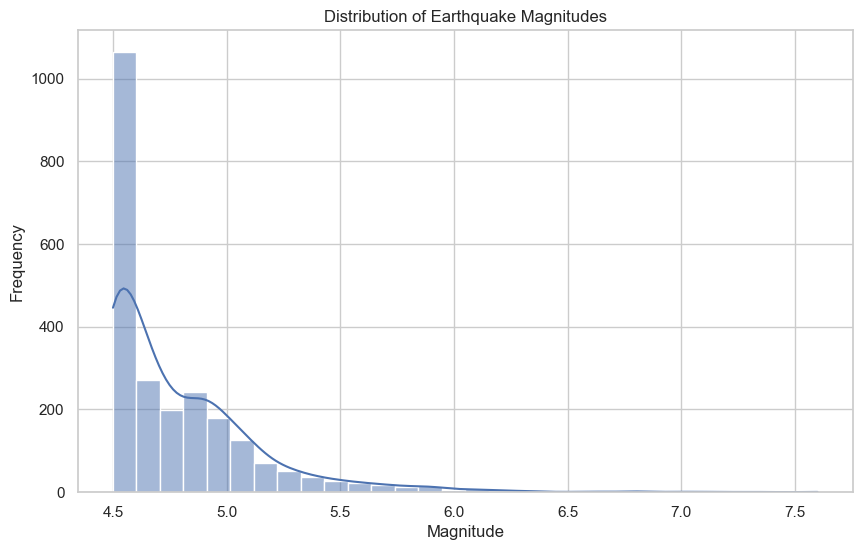

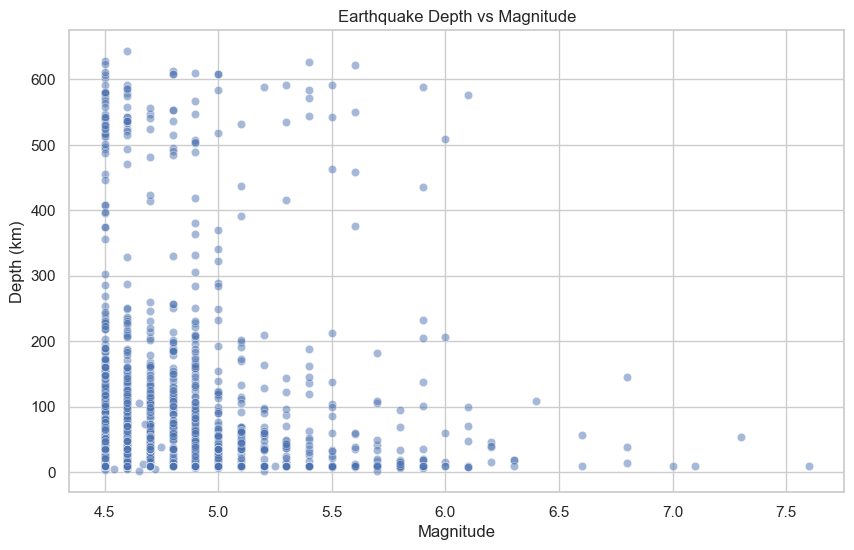

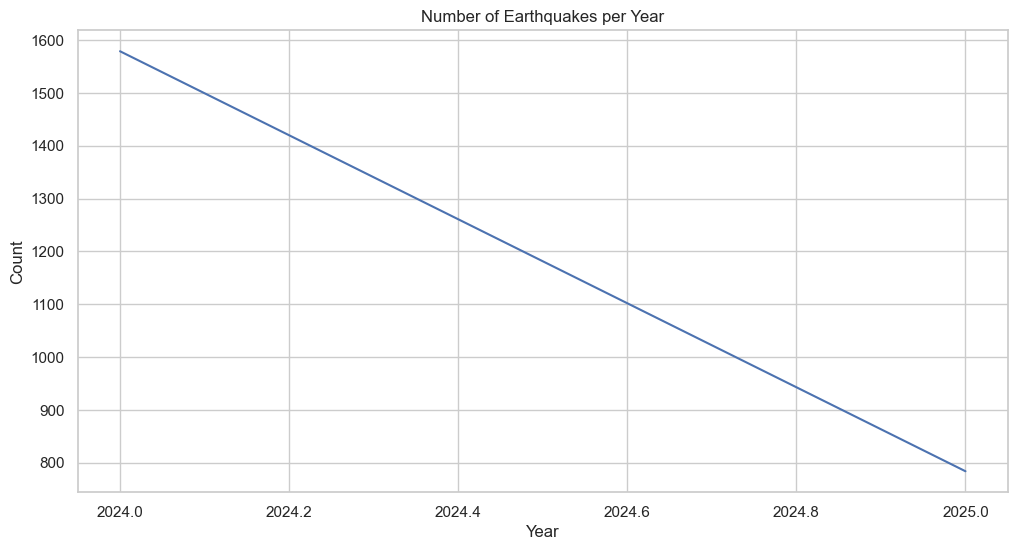

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better aesthetics
sns.set(style="whitegrid")

# Distribution of Magnitudes
plt.figure(figsize=(10,6))
sns.histplot(df_cleaned['magnitude'], bins=30, kde=True)
plt.title('Distribution of Earthquake Magnitudes')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.show()

# Depth vs Magnitude
plt.figure(figsize=(10,6))
sns.scatterplot(x='magnitude', y='depth', data=df_cleaned, alpha=0.5)
plt.title('Earthquake Depth vs Magnitude')
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.show()

# Time Series Analysis - Number of Earthquakes Over Time
df_cleaned['year'] = df_cleaned['timestamp'].dt.year
yearly_counts = df_cleaned['year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values)
plt.title('Number of Earthquakes per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

### Explanation:

#### Magnitude Distribution: Understanding how magnitudes are distributed helps identify typical ranges and outliers.
#### Depth vs Magnitude: Examining this relationship can reveal trends about where larger earthquakes occur.
#### Temporal Trends: Analyzing the number of earthquakes over time can highlight increasing or decreasing frequencies.

### 4. Visualization
#### Objective: Create more advanced visualizations to explore spatial and temporal patterns.

#### a. Geospatial Visualization
##### We use folium to create interactive maps displaying earthquake locations.

In [10]:
import folium

# Sample the data for better performance
df_sampled = df_cleaned.sample(n=1000, random_state=42)

# Create a base map centered around the mean coordinates
mean_lat = df_sampled['latitude'].mean()
mean_lon = df_sampled['longitude'].mean()
m = folium.Map(location=[mean_lat, mean_lon], zoom_start=2)

# Add markers for each earthquake
for idx, row in df_sampled.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=row['magnitude']*2,  # Scale radius by magnitude
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.6,
        popup=f"Magnitude: {row['magnitude']}<br>Depth: {row['depth']} km"
    ).add_to(m)

# Save the map to an HTML file
m.save('earthquake_map.html')

# Optionally, display the map in Jupyter Notebook
import IPython
IPython.display.IFrame('earthquake_map.html', width=800, height=600)

### Explanation:

#### Interactive Map: Each earthquake is represented as a circle marker, with size proportional to magnitude. Clicking on a marker reveals additional details.
#### Performance Consideration: Sampling the data prevents rendering issues with large datasets.

### b. Heatmaps
#### Visualize earthquake density using heatmaps.

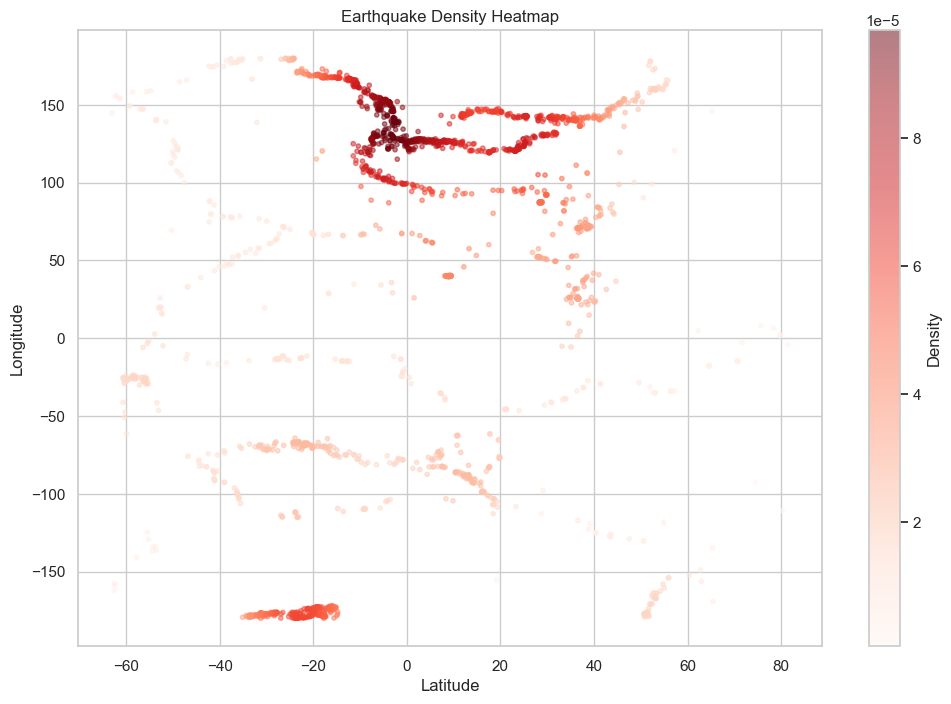

In [11]:
from scipy.stats import gaussian_kde

# Extract coordinates
coords = df_cleaned[['latitude', 'longitude']].values

# Compute kernel density estimate
kde = gaussian_kde(coords.T)
density = kde(coords.T)

# Create a scatter plot with density coloring
plt.figure(figsize=(12,8))
sc = plt.scatter(coords[:,0], coords[:,1], c=density, cmap='Reds', s=10, alpha=0.5)
plt.colorbar(sc, label='Density')
plt.title('Earthquake Density Heatmap')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.show()

### Explanation:

#### Kernel Density Estimate (KDE): Smooths out the data points to represent areas of higher earthquake concentration.

### 5. Advanced Analysis
#### Objective: Perform deeper analyses such as clustering, anomaly detection, and statistical modeling.

### a. Clustering Earthquake Locations
#### Use K-Means clustering to identify regions with high earthquake activity.

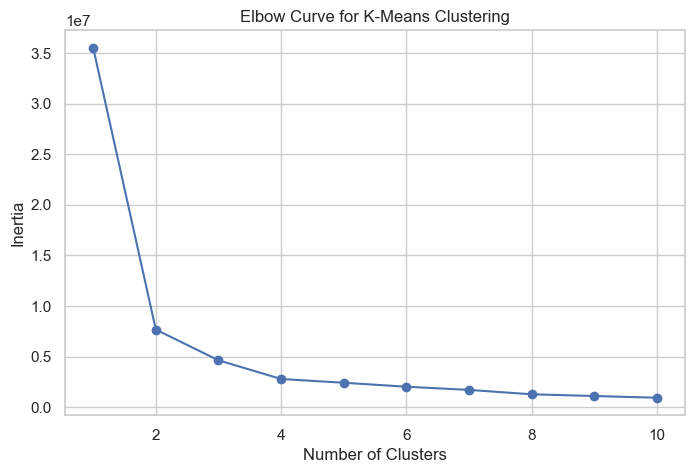

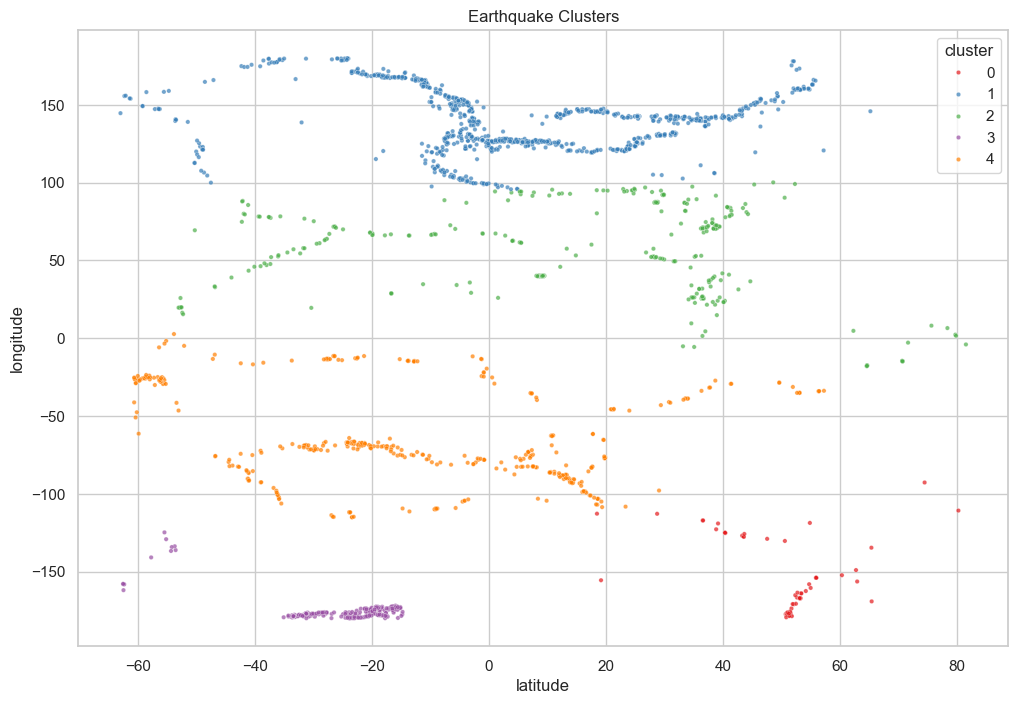

In [12]:
from sklearn.cluster import KMeans

# Select latitude and longitude for clustering
X = df_cleaned[['latitude', 'longitude']]

# Determine optimal number of clusters using the Elbow Method
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Curve for K-Means Clustering')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Apply K-Means with chosen number of clusters (e.g., 5)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_cleaned['cluster'] = kmeans.fit_predict(X)

# Visualize clusters
plt.figure(figsize=(12,8))
sns.scatterplot(x='latitude', y='longitude', hue='cluster', palette='Set1', data=df_cleaned, s=10, alpha=0.7)
plt.title('Earthquake Clusters')
plt.show()

### Explanation:

#### Elbow Method: This method helps determine the optimal number of clusters by identifying the "elbow" point where inertia decreases significantly.
#### Cluster Visualization: Different colors represent distinct clusters, highlighting regional patterns.

### b. Anomaly Detection
#### Identify unusual earthquakes based on magnitude and depth.

In [13]:
from scipy import stats

# Z-score for magnitude and depth
df_cleaned['z_mag'] = stats.zscore(df_cleaned['magnitude'])
df_cleaned['z_depth'] = stats.zscore(df_cleaned['depth'])

# Define anomalies as points beyond 3 standard deviations
anomalies = df_cleaned[(abs(df_cleaned['z_mag']) > 3) | (abs(df_cleaned['z_depth']) > 3)]

# Display anomalies
print(anomalies[['timestamp', 'latitude', 'longitude', 'magnitude', 'depth']])

                            timestamp  latitude  longitude  magnitude    depth
13   2025-02-10 03:51:39.953000+00:00  -21.5598  -179.3594        4.5  602.280
16   2025-02-10 00:09:43.093000+00:00  -17.4593   167.7720        5.9   18.000
28   2025-02-09 03:38:59.958000+00:00  -23.7161  -179.9140        4.7  524.658
32   2025-02-08 23:23:14.341000+00:00   17.7016   -82.4564        7.6   10.000
54   2025-02-07 10:27:01.029000+00:00  -23.9177  -176.1430        6.0   59.227
...                               ...       ...        ...        ...      ...
2306 2024-10-03 19:30:49.709000+00:00  -17.7137  -178.4049        4.5  530.548
2329 2024-10-02 08:11:53.594000+00:00  -20.4577  -178.3572        4.5  542.566
2338 2024-10-01 21:19:49.760000+00:00   14.1621   124.8171        5.9   10.000
2341 2024-10-01 20:05:34.967000+00:00  -19.2886  -173.0007        6.6   10.000
2350 2024-10-01 09:28:05.313000+00:00   -5.9828   124.8988        6.1  576.000

[142 rows x 5 columns]


### Explanation:

#### Z-Score: Standardizes the data to identify outliers based on their deviation from the mean.
#### Anomalies: Earthquakes with extreme magnitudes or depths may warrant further investigation.

### c. Statistical Modeling
#### Fit a regression model to explore the relationship between magnitude and depth.

Mean Squared Error: 0.1300997294578505
R-squared: -0.0015450448615839107


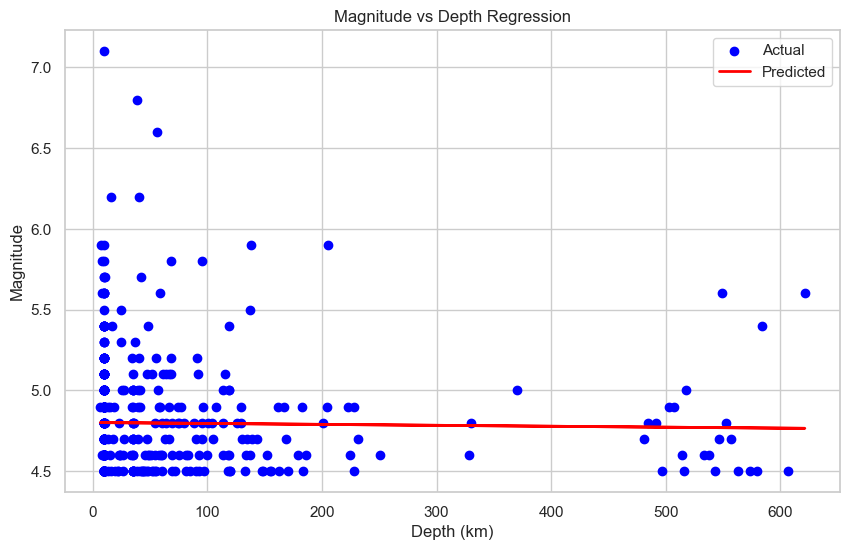

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Prepare data
X = df_cleaned[['depth']]
y = df_cleaned['magnitude']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Plot the regression line
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.title('Magnitude vs Depth Regression')
plt.xlabel('Depth (km)')
plt.ylabel('Magnitude')
plt.legend()
plt.show()

### Explanation:

#### Linear Regression: Models the linear relationship between depth and magnitude.
#### Evaluation Metrics: Assess the model's performance using MSE and R-squared.

### Conclusion
#### This comprehensive guide covers essential steps in analyzing an earthquake dataset using Python. From loading and cleaning the data to performing exploratory analysis, visualization, and advanced techniques like clustering and regression, these methods provide a robust framework for gaining insights into seismic activity patterns.